# FIFA 23 Players Dataset — Data Preprocessing
**Project 8: FIFA Players Statistics Dashboard**

Cleans, explores and engineers features for the dashboard.

Dataset: https://www.kaggle.com/datasets/stefanoleone992/fifa-23-complete-player-dataset

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

COLORS = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800',
          '#00BCD4','#E91E63','#607D8B','#8BC34A','#FF5252']

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Raw Dataset

In [2]:
# Full Kaggle file: df = pd.read_csv('data/male_players.csv', low_memory=False)
df = pd.read_csv('data/male_players.csv', nrows=5000)

print(f'Shape: {df.shape}')
df.head()

Shape: (5000, 110)


,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
0,158023,/player/158023/lionel-messi/230009,23,9,2023-01-13,L. Messi,Lionel Andrés Messi Cuccittini,RW,91,91,...,63+3,63+3,64+3,59+3,50+3,50+3,50+3,59+3,19+3,https://cdn.sofifa.net/players/158/023/23_120.png
1,165153,/player/165153/karim-benzema/230009,23,9,2023-01-13,K. Benzema,Karim Benzema,"CF, ST",91,91,...,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3,https://cdn.sofifa.net/players/165/153/23_120.png
2,188545,/player/188545/robert-lewandowski/230009,23,9,2023-01-13,R. Lewandowski,Robert Lewandowski,ST,91,91,...,66+3,66+3,64+3,61+3,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/23_120.png
3,192985,/player/192985/kevin-de-bruyne/230009,23,9,2023-01-13,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,79+3,79+3,78+3,74+3,68+3,68+3,68+3,74+3,21+3,https://cdn.sofifa.net/players/192/985/23_120.png
4,231747,/player/231747/kylian-mbappe/230009,23,9,2023-01-13,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,95,...,63+3,63+3,67+3,63+3,54+3,54+3,54+3,63+3,18+3,https://cdn.sofifa.net/players/231/747/23_120.png


## 3. Dataset Info & Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 110 entries, player_id to player_face_url
dtypes: float64(17), int64(46), str(47)
memory usage: 4.2 MB


## 4. Descriptive Statistics

In [4]:
numeric_cols = ['age','height_cm','weight_kg','overall','potential',
                'value_eur','wage_eur','pace','shooting','passing',
                'dribbling','defending','physic']

df[numeric_cols].describe().round(2)

,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
count,5000.00,5000.00,5000.00,5000.00,5000.00,4.949000e+03,4956.00,4516.00,4516.00,4516.00,4516.00,4516.00,4516.00
mean,27.45,181.91,76.18,74.11,76.28,8.236878e+06,25236.13,70.48,60.72,66.11,70.30,58.95,70.54
std,4.14,6.88,7.19,3.77,4.71,1.313298e+07,31567.45,11.98,13.67,8.30,8.09,16.93,8.28
min,17.00,156.00,55.00,70.00,70.00,1.800000e+05,500.00,29.00,18.00,35.00,36.00,19.00,35.00
25%,24.00,177.00,71.00,71.00,72.00,2.000000e+06,8000.00,64.00,52.00,61.00,67.00,42.75,66.00
50%,27.00,182.00,76.00,73.00,75.00,3.600000e+06,16000.00,72.00,65.00,67.00,72.00,67.00,72.00
75%,30.00,187.00,81.00,76.00,79.00,8.000000e+06,30000.00,79.00,71.00,72.00,75.00,72.00,77.00
max,44.00,203.00,103.00,91.00,95.00,1.905000e+08,450000.00,97.00,91.00,93.00,94.00,90.00,89.00


## 5. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
result = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
result = result[result['Missing Count'] > 0]

if result.empty:
    print('No missing values ✅')
else:
    print(result)

                                Missing Count  Missing %
value_eur                                  51       1.02
wage_eur                                   44       0.88
league_id                                  44       0.88
league_name                                44       0.88
league_level                               44       0.88
club_team_id                               44       0.88
club_name                                  44       0.88
club_position                              44       0.88
club_jersey_number                         44       0.88
club_loaned_from                         4657      93.14
club_joined_date                          387       7.74
club_contract_valid_until_year             44       0.88
nation_team_id                           4355      87.10
nation_position                          4355      87.10
nation_jersey_number                     4355      87.10
release_clause_eur                        394       7.88
player_tags                    

## 6. Duplicates

In [6]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
df = df.drop_duplicates()
print(f'Shape after dedup: {df.shape}')

Duplicate rows: 0
Shape after dedup: (5000, 110)


## 7. Remove Invalid Rows

In [7]:
before = len(df)

df = df[(df['age'] >= 15) & (df['age'] <= 45)]
df = df[(df['overall'] >= 40) & (df['overall'] <= 99)]

skill_cols = ['pace','shooting','passing','dribbling','defending','physic']
for col in skill_cols:
    df = df[(df[col] >= 1) & (df[col] <= 99)]

df = df.dropna(subset=['overall','player_positions','club_name','league_name'])

print(f'Removed: {before - len(df)} rows')
print(f'Clean shape: {df.shape}')

Removed: 520 rows
Clean shape: (4480, 110)


## 8. Feature Engineering

In [8]:
df['value_M']  = (df['value_eur'] / 1_000_000).round(2)
df['wage_K']   = (df['wage_eur']  / 1_000).round(1)
df['avg_skill'] = df[skill_cols].mean(axis=1).round(1)

def position_group(pos):
    p = str(pos).split(',')[0].strip()
    if p == 'GK':                        return 'Goalkeeper'
    if p in ['CB','LB','RB','LWB','RWB']:return 'Defender'
    if p in ['CDM','CM','CAM','LM','RM']:return 'Midfielder'
    return 'Forward'

df['position_group']    = df['player_positions'].apply(position_group)
df['growth_potential']  = df['potential'] - df['overall']

print(df[['value_M','wage_K','avg_skill','position_group','growth_potential']].head())

   value_M  wage_K  avg_skill position_group  growth_potential
0     54.0   195.0       75.3        Forward                 0
1     64.0   450.0       75.8        Forward                 0
2     84.0   420.0       76.3        Forward                 0
3    107.5   350.0       80.3     Midfielder                 0
4    190.5   230.0       78.3        Forward                 4


## 9. Exploratory Data Analysis (EDA)

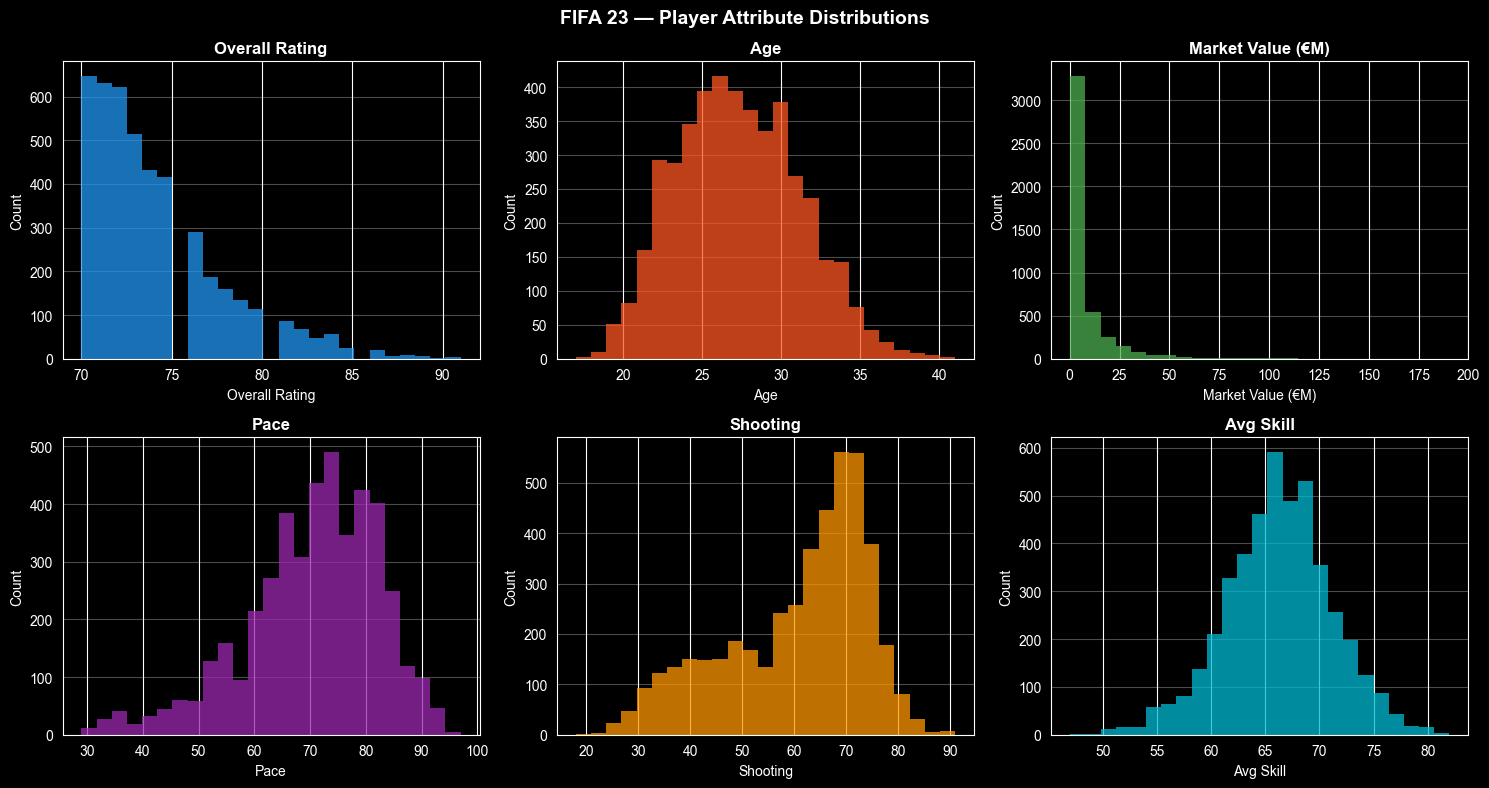

Saved: data/eda_distributions.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('FIFA 23 — Player Attribute Distributions', fontsize=14, fontweight='bold')

metrics = [('overall','Overall Rating'),('age','Age'),('value_M','Market Value (€M)'),
           ('pace','Pace'),('shooting','Shooting'),('avg_skill','Avg Skill')]

for ax, (col, label), color in zip(axes.flat, metrics, COLORS):
    ax.hist(df[col].dropna(), bins=25, color=color, alpha=0.75, edgecolor='none')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/eda_distributions.png')

## 10. Correlation Heatmap

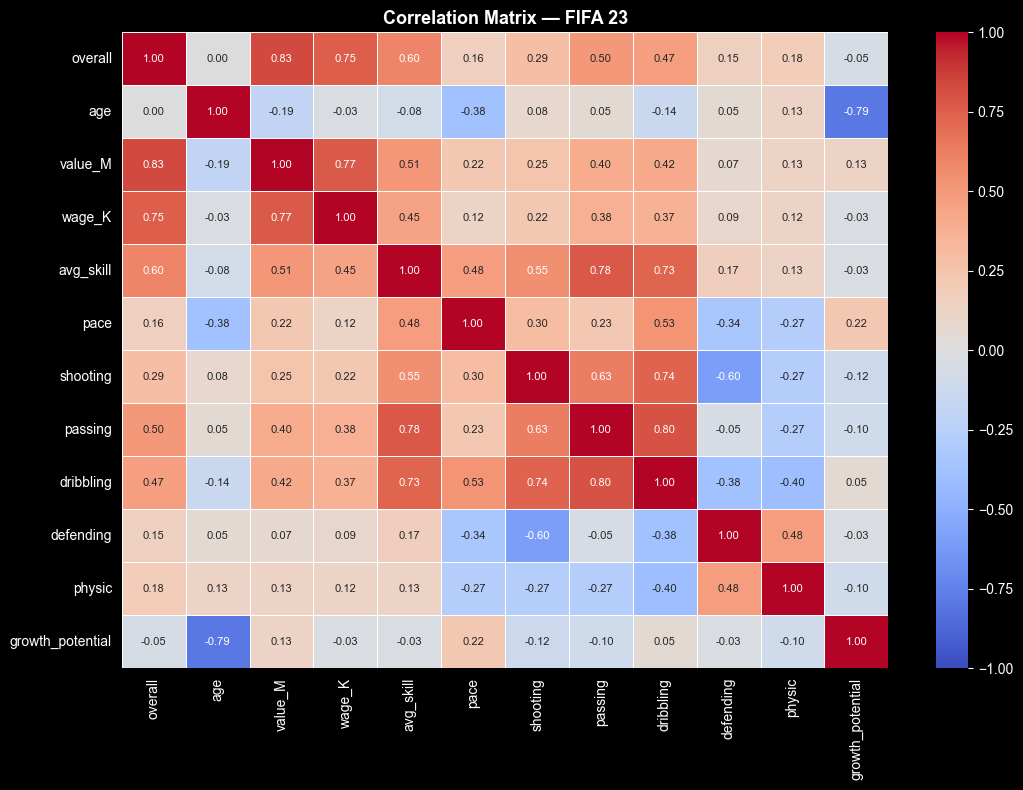

Top correlations with Overall:
overall             1.00
value_M             0.83
wage_K              0.75
avg_skill           0.60
passing             0.50
dribbling           0.47
shooting            0.29
physic              0.18
pace                0.16
defending           0.15
age                 0.00
growth_potential   -0.05


In [10]:
corr_cols = ['overall','age','value_M','wage_K','avg_skill',
             'pace','shooting','passing','dribbling','defending',
             'physic','growth_potential']

corr = df[corr_cols].corr().round(2)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size':8})
plt.title('Correlation Matrix — FIFA 23', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top correlations with Overall:')
print(corr['overall'].sort_values(ascending=False).to_string())

## 11. Dataset Summary

In [11]:
print('=== Players per League ===')
print(df['league_name'].value_counts().to_string())

print('\n=== Players per Position ===')
print(df['player_positions'].value_counts().to_string())

print('\n=== Players per FIFA Edition ===')
print(df['fifa_version'].value_counts().sort_index().to_string())

=== Players per League ===
league_name
Serie A                587
Premier League         452
La Liga                400
Bundesliga             369
Ligue 1                307
Championship           234
Liga Profesional       203
Super Lig              186
Major League Soccer    173
Liga Portugal          170
Jupiler Pro League     147
La Liga 2              145
Super League           134
Serie B                129
Eredivisie             114
2. Bundesliga          103
Pro League              98
Fortuna Liga            59
Ligue 2                 54
Premiership             51
Primera Division        45
Superliga               41
K League 1              41
Liga BetPlay            40
Allsvenskan             31
Primera División        26
1. HNL                  23
Ekstraklasa             23
Liga Pro                21
Eliteserien             19
A-League                16
NB I.                   13
Liga 1                  12
1. Division              6
League One               4
3. Liga         

## 12. Save Cleaned Dataset

In [12]:
df.to_csv('data/male_players_cleaned.csv', index=False)

print(f'Saved: {df.shape[0]} rows × {df.shape[1]} columns')
print('Columns:', list(df.columns))
print('Ready for the dashboard ✅')

Saved: 4480 rows × 115 columns
Columns: ['player_id', 'player_url', 'fifa_version', 'fifa_update', 'fifa_update_date', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'league_id', 'league_name', 'league_level', 'club_team_id', 'club_name', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'mov